In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

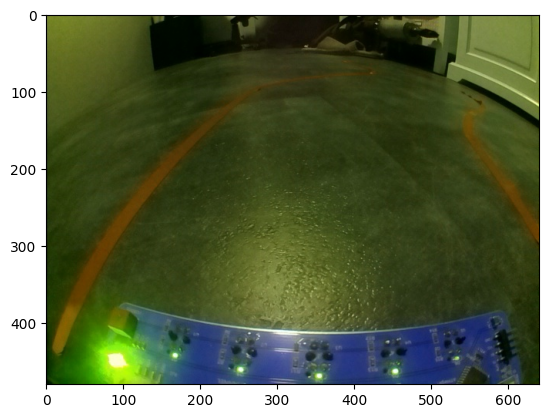

In [3]:
path = "img/car_img_2025-03-18_10-53-51.131396.jpg"
img = cv2.imread(path)
plt.imshow(img)

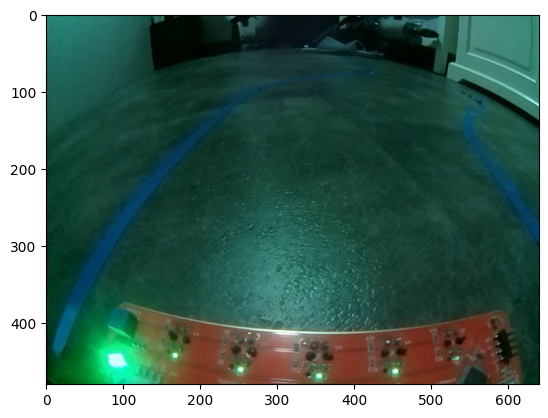

In [4]:
plt.imshow(img[:, :, ::-1])

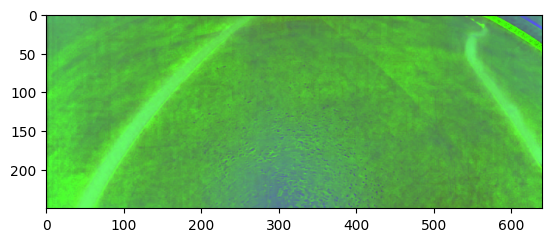

In [9]:
img_crop = img[100:350,:,:]
img_hsv = cv2.cvtColor(img_crop, cv2.COLOR_BGR2HSV)
plt.imshow(img_hsv)

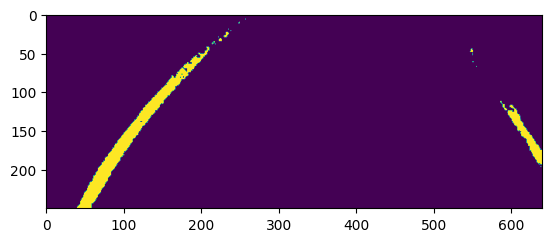

In [10]:
lower_blue = np.array([100, 150, 0])
upper_blue = np.array([140, 255, 255])
mask = cv2.inRange(img_hsv, lower_blue, upper_blue)
plt.imshow(mask)

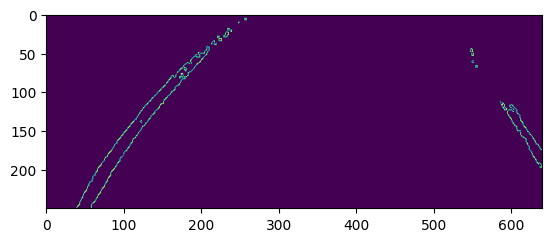

In [11]:
edges = cv2.Canny(mask, 50, 150, apertureSize=3)
plt.imshow(edges)

In [18]:
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=10)
print(lines)

[[[179  83 235  18]]

 [[123 146 178  80]]

 [[ 76 184 131 114]]

 [[ 72 224 112 161]]

 [[127 142 183  75]]

 [[588 114 638 197]]]


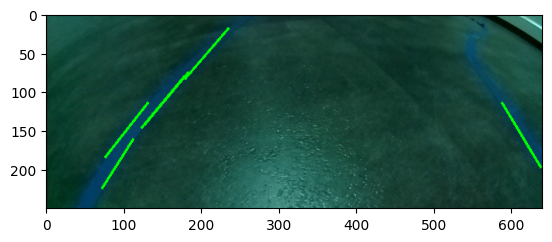

In [32]:
line_img = img_crop.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
    
plt.imshow(line_img[:,:,::-1])

In [24]:
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        
        # Berechnung der Steigung
        if (x2 - x1) != 0:
            slope = (y2 - y1) / (x2 - x1)
            angle_rad = np.arctan(slope)
            angle_deg = np.degrees(angle_rad) 
        else:
            slope = float('inf') 

        print(f"Linie von ({x1},{y1}) nach ({x2},{y2}) hat eine Steigung von {slope}, Winkel {angle_deg}")

Linie von (179,83) nach (235,18) hat eine Steigung von -1.1607142857142858, Winkel -49.253836436119194
Linie von (123,146) nach (178,80) hat eine Steigung von -1.2, Winkel -50.19442890773481
Linie von (76,184) nach (131,114) hat eine Steigung von -1.2727272727272727, Winkel -51.84277341263094
Linie von (72,224) nach (112,161) hat eine Steigung von -1.575, Winkel -57.5876933816488
Linie von (127,142) nach (183,75) hat eine Steigung von -1.1964285714285714, Winkel -50.11041756103123
Linie von (588,114) nach (638,197) hat eine Steigung von 1.66, Winkel 58.93483511450135
